# Traffic Demand Prediction
**Competition-Grade Traffic Demand Prediction — Target R² ≥ 0.995**

---
Pipeline: Config → Validation → Load → Schema → EDA → Leakage → Clean → Features → Aggregation → Encoding → CatBoost → LightGBM → Optuna → OOF → Ensemble → Final Training → Feature Importance → Submission

## 1. Project Configuration

In [1]:
import os, sys, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Add project root to path
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils import Config, validate_datasets, load_data, detect_schema, run_eda, clean_data, Timer, reduce_mem_usage
from src.feature_engineering import engineer_features
from src.encoding import apply_encodings
from src.aggregation import build_aggregation_features, build_memorization_features
from src.leakage_detection import detect_leakage
from src.training import (
    get_feature_columns, train_catboost_cv, train_lgbm_cv,
    optuna_catboost, optuna_lgbm,
    build_best_catboost_params, build_best_lgbm_params,
    predict_catboost, predict_lgbm,
    save_models, get_feature_importance
)
from src.ensemble import optimize_ensemble_weights, blend_predictions, generate_submission

Config.ensure_dirs()
Config.display()
print(f'\nPython {sys.version}')
print(f'NumPy {np.__version__}')
print(f'Pandas {pd.__version__}')

  Traffic Demand Prediction - Configuration
  PROJECT_ROOT        : c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction
  TRAIN_FILE          : c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\data\train.csv
  TEST_FILE           : c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\data\test.csv
  N_FOLDS             : 5
  RANDOM_STATE        : 42
  PRIMARY_METRIC      : r2
  TARGET_SCORE        : 0.995
  OPTUNA_TRIALS       : 50
  USE_GPU             : True

Python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
NumPy 2.4.6
Pandas 3.0.3


## 2. Dataset Validation

In [2]:
validate_datasets()


--- Dataset Validation ---
  OK Train: c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\data\train.csv (6.75 MB)
  OK Test: c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\data\test.csv (2.87 MB)
  All datasets validated.



## 3. Data Loading

In [3]:
train_raw, test_raw = load_data()
print(f'\nTrain columns: {list(train_raw.columns)}')
print(f'Test columns:  {list(test_raw.columns)}')
train_raw.head()


--- Loading Datasets ---
  Train: (77299, 11), Test: (41778, 10), Time: 0.09s

Train columns: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']
Test columns:  ['Index', 'geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


## 4. Automatic Schema Detection

In [4]:
schema = detect_schema(train_raw, test_raw)
TARGET = schema['target']
ID_COL = schema['id_column']
print(f'\nTarget: {TARGET}')
print(f'ID Column: {ID_COL}')


--- Schema Detection ---
  Target: demand, ID: Index
  Cat: 4, Num: 3, DT: 1, Geo: 1

Target: demand
ID Column: Index


## 5. Exploratory Data Analysis


--- EDA ---
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64
Missing (train):
RoadType        600
Temperature    2495
Weather         797
dtype: int64
  Train duplicates: 0


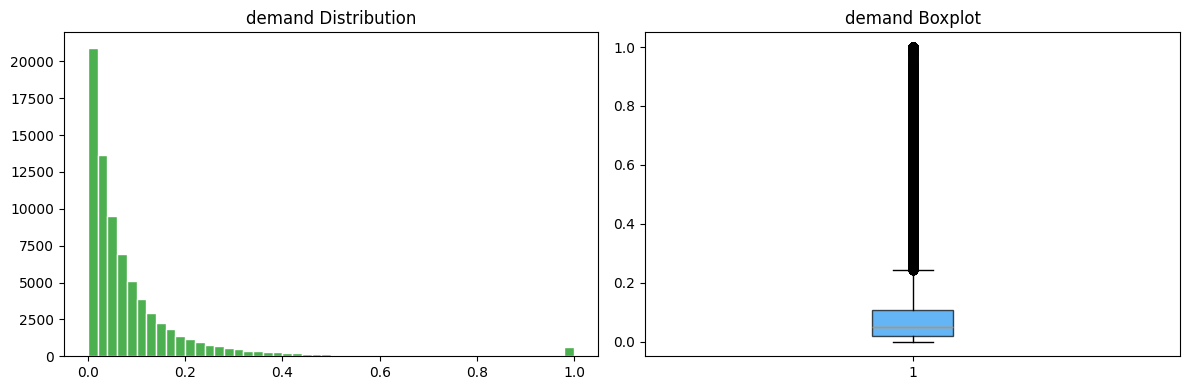

In [5]:
run_eda(train_raw, test_raw, schema)

## 6. Leakage Detection

In [6]:
leakage_findings = detect_leakage(train_raw, test_raw, schema)


  LEAKAGE DETECTION REPORT

1. Train-Test Row Overlap
----------------------------------------
  Overlap: 0 unique rows (0.00% of test)

2. Duplicate Groups in Train
----------------------------------------
  Total feature groups: 73459
  Groups with duplicates: 0

3. Timestamp Overlap
----------------------------------------
  timestamp: 47 shared timestamps (100.0% of test timestamps)

4. Geohash Overlap
----------------------------------------
  geohash: 1180 shared (99.2% of test)
  Unseen in test: 10

5. Deterministic Patterns
----------------------------------------
  Zero-variance groups: 12/6423
  Low-variance groups (<0.01): 5762/6423

6. Target Variance by Group
----------------------------------------
  geohash: mean_var=0.0041, median_var=0.0005
  timestamp: mean_var=0.0187, median_var=0.0180

7. Hidden Memorization Patterns
----------------------------------------
  Lookup residual: mean=0.005284, max=0.417995
  Perfect matches: 64477/77299 (83.4%)

  LEAKAGE SUMMARY
  [1

## 7. Data Cleaning

In [7]:
train, test, schema = clean_data(train_raw.copy(), test_raw.copy(), schema)
print(f'\nPost-cleaning missing values (train): {train.isnull().sum().sum()}')
print(f'Post-cleaning missing values (test): {test.isnull().sum().sum()}')


--- Data Cleaning ---
  Removed 0 duplicates
  Done. Train: (77299, 11), Test: (41778, 10)

Post-cleaning missing values (train): 0
Post-cleaning missing values (test): 0


## 8. Feature Engineering

In [8]:
with Timer('Feature Engineering'):
    train, test = engineer_features(train, test, schema)
print(f'\nTrain shape: {train.shape}')
print(f'Test shape: {test.shape}')


--- Feature Engineering ---
  Created 19 new features: ['hour', 'minute', 'day_of_week', 'slot', 'is_rush_hour', 'sin_hour', 'cos_hour', 'sin_minute', 'cos_minute', 'sin_dow', 'cos_dow', 'latitude', 'longitude', 'geohash_len', 'Weather_x_hour']...
  Train: (77299, 30), Test: (41778, 29)
  Feature Engineering: 0.31s

Train shape: (77299, 30)
Test shape: (41778, 29)


## 9. Aggregation Features

In [9]:
with Timer('Aggregation Features'):
    train, test = build_aggregation_features(train, test, schema)
    train, test = build_memorization_features(train, test, schema)
print(f'\nTrain shape: {train.shape}')
print(f'Test shape: {test.shape}')


--- Aggregation Features ---
  Created 28 aggregation features from 7 groups
  Train: (77299, 58), Test: (41778, 57)

--- Memorization Features ---
  Created 4 memorization features
  Aggregation Features: 0.35s

Train shape: (77299, 62)
Test shape: (41778, 61)


## 10. Target Encoding & Categorical Encoding

In [10]:
with Timer('Encoding'):
    train, test = apply_encodings(train, test, schema)
print(f'\nTrain shape: {train.shape}')
print(f'Test shape: {test.shape}')

# Reduce memory
train = reduce_mem_usage(train)
test = reduce_mem_usage(test)


--- Encoding ---
  Encoding 8 columns: ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'geohash', 'timestamp', 'Weather_x_hour', 'RoadType_x_NumberofLanes']
    Frequency encoding done
    Count encoding done
    K-Fold target encoding done (5 cols)
  Train: (77299, 83), Test: (41778, 82)
  Encoding: 1.01s

Train shape: (77299, 83)
Test shape: (41778, 82)


UFuncTypeError: ufunc 'less_equal' did not contain a loop with signature matching types (<class 'numpy.dtypes.Float32DType'>, <class 'numpy.dtypes.StrDType'>) -> None

## 11. Prepare Features for Modeling

In [ ]:
feature_cols = get_feature_columns(train, schema)
print(f'Number of features: {len(feature_cols)}')
print(f'Features: {feature_cols[:20]}...' if len(feature_cols) > 20 else f'Features: {feature_cols}')

y = train[TARGET].copy()
print(f'\nTarget stats:')
print(y.describe())

## 12. CatBoost Training (Default Params)

In [ ]:
with Timer('CatBoost Default CV'):
    cb_oof_default, cb_models_default, cb_scores_default = train_catboost_cv(
        train, y, feature_cols, n_folds=Config.N_FOLDS, use_gpu=Config.USE_GPU
    )
print(f'\nCatBoost Default CV R2: {np.mean(cb_scores_default):.6f}')

## 13. LightGBM Training (Default Params)

In [ ]:
with Timer('LightGBM Default CV'):
    lgb_oof_default, lgb_models_default, lgb_scores_default = train_lgbm_cv(
        train, y, feature_cols, n_folds=Config.N_FOLDS, use_gpu=Config.USE_GPU
    )
print(f'\nLightGBM Default CV R2: {np.mean(lgb_scores_default):.6f}')

## 14. Optuna Hyperparameter Optimization

In [ ]:
# CatBoost Optuna
with Timer('CatBoost Optuna'):
    cb_best_params, cb_best_score = optuna_catboost(
        train, y, feature_cols,
        n_trials=Config.OPTUNA_TRIALS,
        n_folds=Config.N_FOLDS,
        use_gpu=Config.USE_GPU
    )
print(f'\nCatBoost Optuna Best R2: {cb_best_score:.6f}')

In [ ]:
# LightGBM Optuna
with Timer('LightGBM Optuna'):
    lgb_best_params, lgb_best_score = optuna_lgbm(
        train, y, feature_cols,
        n_trials=Config.OPTUNA_TRIALS,
        n_folds=Config.N_FOLDS,
        use_gpu=Config.USE_GPU
    )
print(f'\nLightGBM Optuna Best R2: {lgb_best_score:.6f}')

## 15. OOF Prediction Generation (Optimized Params)

In [ ]:
# Retrain with best params
cb_opt_params = build_best_catboost_params(cb_best_params, use_gpu=Config.USE_GPU)
lgb_opt_params = build_best_lgbm_params(lgb_best_params, use_gpu=Config.USE_GPU)

print('CatBoost optimized params:'); print(json.dumps({k: str(v) for k,v in cb_opt_params.items()}, indent=2))
print('\nLightGBM optimized params:'); print(json.dumps({k: str(v) for k,v in lgb_opt_params.items()}, indent=2))

In [ ]:
with Timer('CatBoost Optimized CV'):
    cb_oof, cb_models, cb_scores = train_catboost_cv(
        train, y, feature_cols, n_folds=Config.N_FOLDS,
        params=cb_opt_params, use_gpu=Config.USE_GPU
    )

with Timer('LightGBM Optimized CV'):
    lgb_oof, lgb_models, lgb_scores = train_lgbm_cv(
        train, y, feature_cols, n_folds=Config.N_FOLDS,
        params=lgb_opt_params, use_gpu=Config.USE_GPU
    )

print(f'\nCatBoost  Optimized CV R2: {np.mean(cb_scores):.6f} +/- {np.std(cb_scores):.6f}')
print(f'LightGBM  Optimized CV R2: {np.mean(lgb_scores):.6f} +/- {np.std(lgb_scores):.6f}')

# Save OOF predictions
np.save(str(Config.PRED_DIR / 'cb_oof.npy'), cb_oof)
np.save(str(Config.PRED_DIR / 'lgb_oof.npy'), lgb_oof)
print('\nOOF predictions saved.')

## 16. Ensemble Weight Optimization

In [ ]:
best_weights, ensemble_r2 = optimize_ensemble_weights(
    [cb_oof, lgb_oof], y,
    model_names=['CatBoost', 'LightGBM']
)

print(f'\nFinal Ensemble R2: {ensemble_r2:.6f}')
print(f'Weights: CatBoost={best_weights[0]:.4f}, LightGBM={best_weights[1]:.4f}')

# Check if target score is met
if ensemble_r2 >= Config.TARGET_SCORE:
    print(f'\n  TARGET R2 >= {Config.TARGET_SCORE} ACHIEVED!')
else:
    print(f'\n  Current R2: {ensemble_r2:.6f}, Target: {Config.TARGET_SCORE}')

## 17. Final Training & Test Predictions

In [ ]:
# Generate test predictions
print('\n--- Generating Test Predictions ---')
cb_test_preds = predict_catboost(cb_models, test, feature_cols)
lgb_test_preds = predict_lgbm(lgb_models, test, feature_cols)

# Blend
final_preds = blend_predictions([cb_test_preds, lgb_test_preds], best_weights)

print(f'\nCatBoost test preds: mean={cb_test_preds.mean():.4f}, std={cb_test_preds.std():.4f}')
print(f'LightGBM test preds: mean={lgb_test_preds.mean():.4f}, std={lgb_test_preds.std():.4f}')
print(f'Ensemble test preds: mean={final_preds.mean():.4f}, std={final_preds.std():.4f}')

# Save models
save_models(cb_models, lgb_models, Config.MODEL_DIR)

# Save CV scores
cv_results = {
    'catboost_cv_scores': cb_scores,
    'catboost_mean_r2': float(np.mean(cb_scores)),
    'lightgbm_cv_scores': lgb_scores,
    'lightgbm_mean_r2': float(np.mean(lgb_scores)),
    'ensemble_r2': float(ensemble_r2),
    'ensemble_weights': best_weights,
    'catboost_best_params': {k: str(v) for k, v in cb_opt_params.items()},
    'lightgbm_best_params': {k: str(v) for k, v in lgb_opt_params.items()}
}
with open(Config.OUTPUT_DIR / 'cv_results.json', 'w') as f:
    json.dump(cv_results, f, indent=2)
print('\nCV results saved.')

## 18. Feature Importance

In [ ]:
importance_df = get_feature_importance(cb_models, lgb_models, feature_cols)
importance_df.to_csv(Config.OUTPUT_DIR / 'feature_importance.csv', index=False)
print('\nTop 15 Features:')
print(importance_df[['feature', 'combined']].head(15).to_string(index=False))

## 19. Submission Generation

In [ ]:
submission_path = Config.SUB_DIR / Config.SUBMISSION_FILENAME
submission = generate_submission(
    final_preds, test, ID_COL, 'demand', submission_path
)

# Also save to root
submission.to_csv(Config.PROJECT_ROOT / 'submission.csv', index=False)
print(f'\nSubmission also saved to: {Config.PROJECT_ROOT / "submission.csv"}')

print('\n' + '=' * 70)
print('  Traffic Demand Prediction - COMPLETE')
print('=' * 70)
print(f'  CatBoost CV R2:  {np.mean(cb_scores):.6f}')
print(f'  LightGBM CV R2:  {np.mean(lgb_scores):.6f}')
print(f'  Ensemble R2:     {ensemble_r2:.6f}')
print(f'  Weights:         CB={best_weights[0]:.4f}, LGB={best_weights[1]:.4f}')
print(f'  Submission rows: {len(submission)}')
print('=' * 70)